In [32]:
import sys
import os
MY_PATH="C:/Users/111075866/Python Code/NSE/../../"
MY_LIB_PATH="C:/Users/111075866/Python Code/NSE"
sys.path.append(MY_LIB_PATH)
sys.path.append(MY_PATH)

from nse_scrap import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as datetime

In [33]:
import import_ipynb
import Stock_Analysis as SA

In [34]:
import yfinance as yf

In [35]:
os.getcwd()

'c:\\python\\Python Code\\NSE'

In [36]:
import warnings
warnings.filterwarnings("ignore")


In [37]:
# yf.download(["BRK-B"],from_date,to_date).fillna(method='backfill')

In [38]:
tkrs = ['THRL.L','BARC.L','RIO.L','LLOY.L','ASML','VHYL.L','VUKG.L','QCOM','BAC','QCOM','WHR','ABR','NLY',
        'UKCM.L','O','EPIC.L','RESI.L','SPR.L','WHR.L','IWDP.L','DPYE.L','UNIT','THRL.L','AEWU.L','NRR.L',
        'IUKP.L','LXI.L','LAND.L','CREI.L','BBOX.L','QCOM','ZIM','ARKO','IIIV','EVRI','ASML','PBR','GLEN.L',
        'VOD','BATS.L','SMT.L','FORT.L','RIO','BARC.L','SGRO.L','GSK','NG',
        'API','AEWU.L','AFCG','ADC','ARE','AAT','AMH','COLD','NLY','APLE','ABR','AHH','AGR','AVB','BCPT.L','TM',
       'TM','KO','MCD','SBUX','PG','CVX','NKE','TSCO.L','RKT.L','ULVR.L','HSBA.L','AV.L','NWG.L', 'RR.L',
        'RGL.L'
        , "SUPR.L", "RGL.L","CREI.L", "AEWU.L","MO", "BMY.L","LGEN.L","WBA","BNPQY","KLAR","NVO","KHC","BRK-B","LLOY.L","BME.L"
       ]

# tkrs = ['API','AEWU.L','AFCG','ADC','ARE','AAT','AMH','COLD','NLY','APLE','ABR','AHH','AGR','AVB','BCPT.L']
# tkrs = ['THRL.L','BARC.L','RIO.L']

# tkrs = ['TM','KO','MCD','SBUX','PG','CVX','NKE','TSCO.L','RKT.L','ULVR.L','HSBA.L','AV.L','NWG.L', 'RR.L']

to_date = (datetime.datetime.now()  + datetime.timedelta(days=0)).strftime("%Y-%m-%d")
# 
from_date = (datetime.datetime.now() + datetime.timedelta(days=-1000)).strftime("%Y-%m-%d")

stk_yf = yf.download(tkrs, from_date, to_date).bfill()
# stk_yf = yf.download(tkrs,'2021-01-01','2023-12-13').fillna(method='backfill')
# stk_yf

[*********************100%***********************]  80 of 80 completed

6 Failed downloads:
['WBA', 'LXI.L', 'AGR', 'EVRI', 'EPIC.L', 'UKCM.L']: YFTzMissingError('possibly delisted; no timezone found')


In [39]:
# yf.download(['BME.L'], from_date, to_date)

In [40]:
from_date, to_date

('2023-04-13', '2026-01-07')

In [41]:
MY_PATH=""
n = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S")
stk_yf.to_csv(MY_PATH+"./dump/UK-STKS-HIS"+n+".csv")

In [42]:
# stk_yf["Close"].symbol
stk_yf["Close"].columns

Index(['AAT', 'ABR', 'ADC', 'AEWU.L', 'AFCG', 'AGR', 'AHH', 'AMH', 'API',
       'APLE', 'ARE', 'ARKO', 'ASML', 'AV.L', 'AVB', 'BAC', 'BARC.L', 'BATS.L',
       'BBOX.L', 'BCPT.L', 'BME.L', 'BMY.L', 'BNPQY', 'BRK-B', 'COLD',
       'CREI.L', 'CVX', 'DPYE.L', 'EPIC.L', 'EVRI', 'FORT.L', 'GLEN.L', 'GSK',
       'HSBA.L', 'IIIV', 'IUKP.L', 'IWDP.L', 'KHC', 'KLAR', 'KO', 'LAND.L',
       'LGEN.L', 'LLOY.L', 'LXI.L', 'MCD', 'MO', 'NG', 'NKE', 'NLY', 'NRR.L',
       'NVO', 'NWG.L', 'O', 'PBR', 'PG', 'QCOM', 'RESI.L', 'RGL.L', 'RIO',
       'RIO.L', 'RKT.L', 'RR.L', 'SBUX', 'SGRO.L', 'SMT.L', 'SPR.L', 'SUPR.L',
       'THRL.L', 'TM', 'TSCO.L', 'UKCM.L', 'ULVR.L', 'UNIT', 'VHYL.L', 'VOD',
       'VUKG.L', 'WBA', 'WHR', 'WHR.L', 'ZIM'],
      dtype='object', name='Ticker')

In [43]:
y_stks = stk_yf["Close"]

sumary = None
for stk in tkrs:
    # print(stk)
    s = y_stks[stk].to_frame()
    s.columns=["close"]    
    s['symbol']=stk
    s = SA.processScrip(s)
    sumary = pd.concat([sumary, s])
    
# t = dfs[ dfs["symbol"]=="ITC"]
# t= processScrip(t)
# u = dfs[ dfs["symbol"]=="INFY"]
# u= processScrip(u)
# print(t)

************
Date
2023-04-13    105.367966
2023-04-14    105.367966
2023-04-17    105.367966
2023-04-18    105.367966
2023-04-19    105.367966
                 ...    
2025-12-30    105.367966
2025-12-31    105.367966
2026-01-02    105.367966
2026-01-05    105.367966
2026-01-06    105.367966
Name: 52WH, Length: 703, dtype: float64
************
************
Date
2023-04-13    488.399994
2023-04-14    488.399994
2023-04-17    488.399994
2023-04-18    488.399994
2023-04-19    488.399994
                 ...    
2025-12-30    488.399994
2025-12-31    488.399994
2026-01-02    488.399994
2026-01-05    488.399994
2026-01-06    488.399994
Name: 52WH, Length: 703, dtype: float64
************
************
Date
2023-04-13    6291.0
2023-04-14    6291.0
2023-04-17    6291.0
2023-04-18    6291.0
2023-04-19    6291.0
               ...  
2025-12-30    6291.0
2025-12-31    6291.0
2026-01-02    6291.0
2026-01-05    6291.0
2026-01-06    6291.0
Name: 52WH, Length: 703, dtype: float64
************
******

In [44]:

values_arr = ["close","SMA20_2_200P","SIG","52WH_P","52WL_P","52WHLP","1WHLP","1MHLP","3MHLP","6MHLP","1YHLP"]
pvt = sumary.pivot_table(values=values_arr, columns=["symbol"], index=["Date"])

# pvt = sumary.pivot_table(values=["SMA20_2_200P","SIG","52WH_P","52WL_P","52WHLP"], columns=["symbol"], index=["Date"])

In [45]:
12*30
s.shape


(703, 32)

In [46]:
pvt.to_csv(MY_PATH+"./dump/UK-STKS-HIS-processed-"+n+".csv")

In [ ]:
list = [1,2]
list = *list 
list

TypeError: can't multiply sequence by non-int of type 'float'

In [47]:
pvt.columns

MultiIndex([('1MHLP',    'AAT'),
            ('1MHLP',    'ABR'),
            ('1MHLP',    'ADC'),
            ('1MHLP', 'AEWU.L'),
            ('1MHLP',   'AFCG'),
            ('1MHLP',    'AHH'),
            ('1MHLP',    'AMH'),
            ('1MHLP',    'API'),
            ('1MHLP',   'APLE'),
            ('1MHLP',    'ARE'),
            ...
            ('close',     'TM'),
            ('close', 'TSCO.L'),
            ('close', 'ULVR.L'),
            ('close',   'UNIT'),
            ('close', 'VHYL.L'),
            ('close',    'VOD'),
            ('close', 'VUKG.L'),
            ('close',    'WHR'),
            ('close',  'WHR.L'),
            ('close',    'ZIM')],
           names=[None, 'symbol'], length=817)

In [48]:
SIGNAL_WINDOW=8
i = pvt.SMA20_2_200P.tail(SIGNAL_WINDOW)
i.loc[:, i[(i > -1.0) & (i < 1.0)].any()].T.to_csv(MY_PATH+"./dump/UK-SIGNAL-Detail-"+n+".csv")
ip = i.loc[:, i[(i > -2.0) & (i < 1.0)].any()].T
ip
# temp2 = pts.loc[:,pts[(pts > 0.75*1e6) & (pts < 0.3*1e7)].any() ]

Date,2025-12-24,2025-12-26,2025-12-29,2025-12-30,2025-12-31,2026-01-02,2026-01-05,2026-01-06
symbol,,,,,,,,
AAT,-0.594099,-0.653207,-0.658520,-0.660417,-0.697041,-0.777576,-0.852815,-0.873142
ADC,0.339327,0.160517,-0.015170,-0.131881,-0.254225,-0.391434,-0.545000,-0.743725
AHH,-0.819373,-0.744546,-0.605353,-0.528647,-0.343404,-0.115001,0.119739,0.427001
BRK-B,0.808656,0.678017,0.574316,0.550965,0.530225,0.491670,0.474974,0.456283
DPYE.L,1.146617,1.088865,1.015304,1.006245,1.014859,0.995959,0.975157,0.999145
IUKP.L,-0.392628,-0.401540,-0.414732,-0.347861,-0.315604,-0.323430,-0.285439,-0.214482
IWDP.L,0.295829,0.220343,0.113701,0.048249,-0.006816,-0.040762,-0.072182,-0.076658
MO,-1.942846,-1.998942,-2.056506,-2.112297,-2.153583,-2.187075,-2.291477,-2.445828
PBR,0.677787,0.325935,-0.005655,-0.241218,-0.500592,-0.820098,-1.228815,-1.388318


In [49]:
s = pvt.SIG.tail(SIGNAL_WINDOW)
s.loc[:, s[(s == 1) | (s==-1) ].any()].T.to_csv(MY_PATH+"./dump/UK-SIGNAL-"+n+".csv")
sp  = s.loc[:, s[(s == 1) | (s==-1)  ].any()].T
sp

Date,2025-12-24,2025-12-26,2025-12-29,2025-12-30,2025-12-31,2026-01-02,2026-01-05,2026-01-06
symbol,,,,,,,,
ADC,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0
AHH,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
IWDP.L,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0
PBR,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0
RESI.L,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
UNIT,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


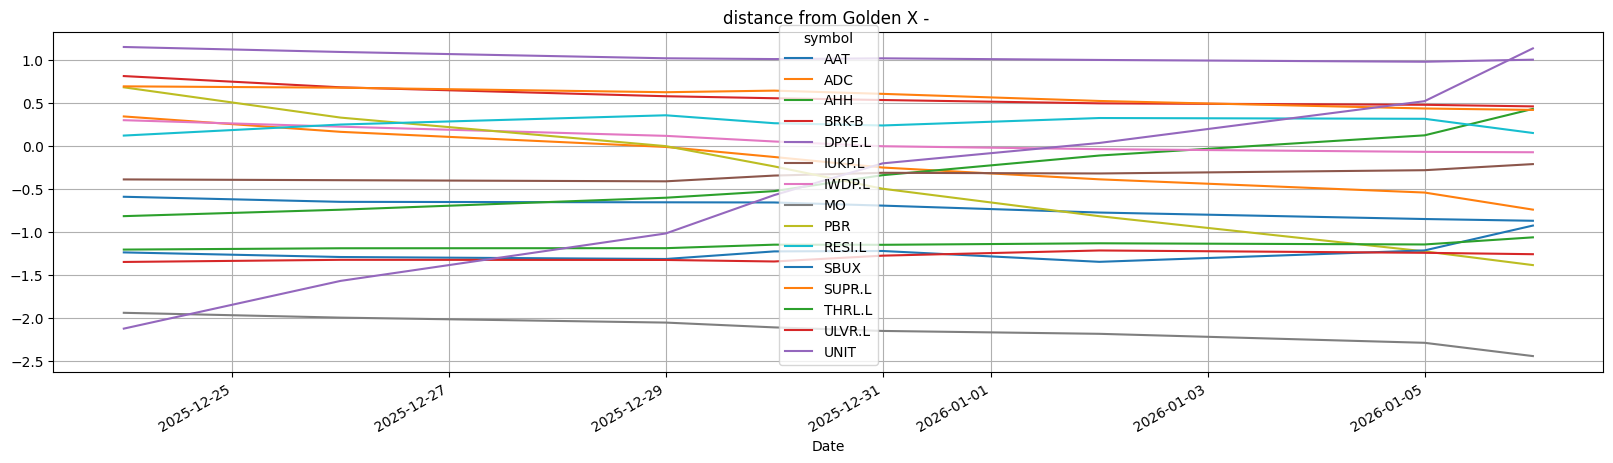

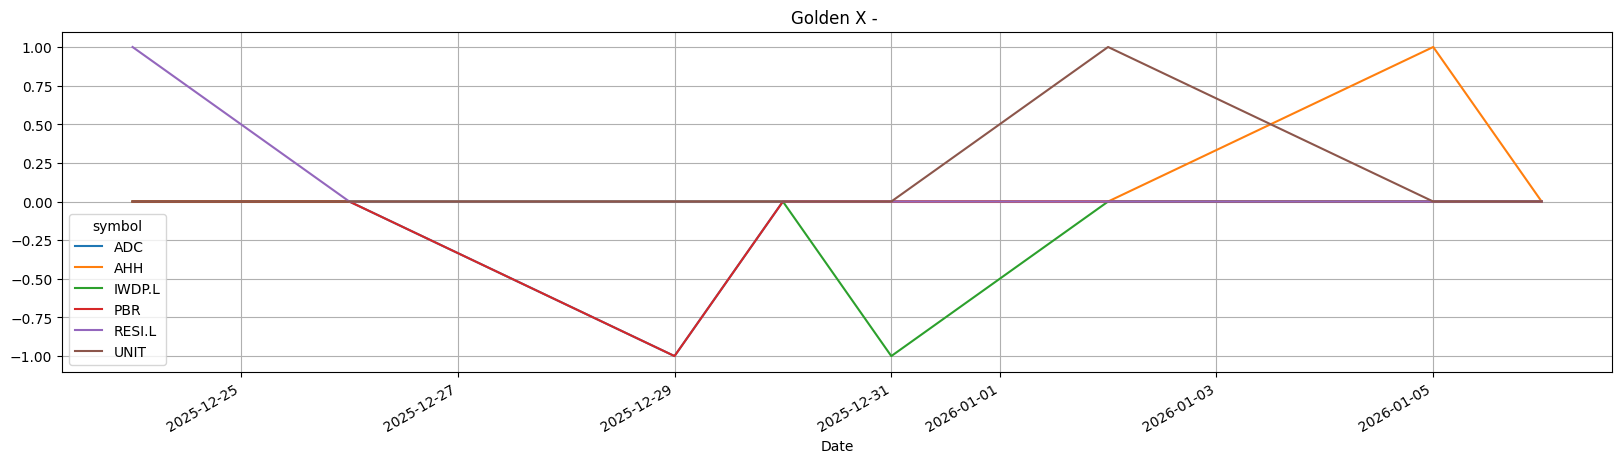

In [50]:
if (ip.shape[0] > 0 ):
    ipfig = ip.T.plot(figsize=(20,5), grid=True, title='distance from Golden X - ').get_figure()
    
if (sp.shape[0] > 0 ):
    spfig = sp.T.plot(figsize=(20,5), grid=True, title='Golden X - ').get_figure()


In [51]:
i52whp = pvt["52WH_P"].tail(5)
i52wlp = pvt["52WL_P"].tail(5)
i52whlp = pvt["52WHLP"].tail(5)

In [52]:
# stocks staying close to 52WL. 
g52wl = i52wlp.loc[:, i52wlp[(i52wlp < 20) ].any()].T
g52wh = i52whp.loc[:, i52whp[(i52whp > 40.0) ].any()].T
g52wl

Date,2025-12-30,2025-12-31,2026-01-02,2026-01-05,2026-01-06
symbol,,,,,
AAT,15.940039,15.209715,14.296804,12.714418,13.079581
ABR,0.909093,0.779226,3.246753,3.636366,3.376626
ADC,5.991456,5.191172,5.322612,4.884494,2.942186
AEWU.L,12.524101,12.943187,14.200436,11.895476,12.524101
AFCG,13.833998,12.648219,12.648219,19.762846,15.810281
AHH,11.111097,12.127364,12.466117,11.957991,13.313004
AMH,7.903593,7.468360,6.865739,5.560050,8.472747
APLE,18.563576,18.065417,20.157716,19.061744,22.449276
ARE,10.006670,10.435411,10.503113,11.789345,18.197939


In [53]:
ULIM_52WH = 90
LLIM_52WH = 25

i52whlpl_all = i52whlp.tail(1).T
i52whlpl_low = i52whlp.tail(1).loc[:, i52whlp[(i52whlp<LLIM_52WH)].any()].T
i52whlpl_high = i52whlp.tail(1).loc[:, i52whlp[(i52whlp>ULIM_52WH)].any()].T
col = i52whlpl_all.columns.values[0]

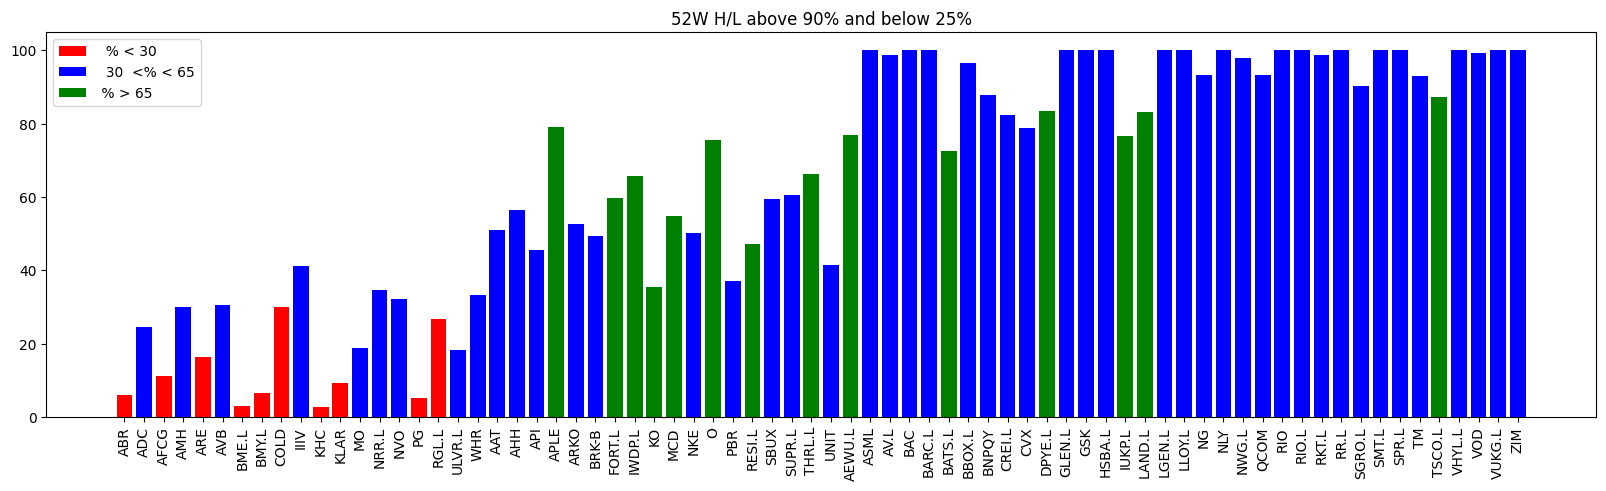

In [54]:
# i52whlpl.plot(kind='bar', figsize=(20,5), grid=True)
plt.figure(figsize=(20,5))
plt.xticks(rotation=90)

i52whlpl_tmp = i52whlp.tail(1).loc[:, i52whlp[(i52whlp<=30)].any()].T
plt.bar(i52whlpl_tmp.index, i52whlpl_tmp[col], color='red', label="  % < 30")

i52whlpl_tmp = i52whlp.tail(1).loc[:, i52whlp[(i52whlp>30) & (i52whlp<=65) ].any()].T
plt.bar(i52whlpl_tmp.index, i52whlpl_tmp[col], color='blue', label="  30  <% < 65")

i52whlpl_tmp = i52whlp.tail(1).loc[:, i52whlp[(i52whlp>65) ].any()].T
plt.bar(i52whlpl_tmp.index, i52whlpl_tmp[col], color='green',label=" % > 65")

plt.bar(i52whlpl_high.index, i52whlpl_high[col], color='blue')
plt.title("52W H/L above {}% and below {}%".format(ULIM_52WH, LLIM_52WH))
plt.legend()
fig52whlclr = plt
fig52whlclr = SA.getImgData(fig52whlclr)
plt.show()

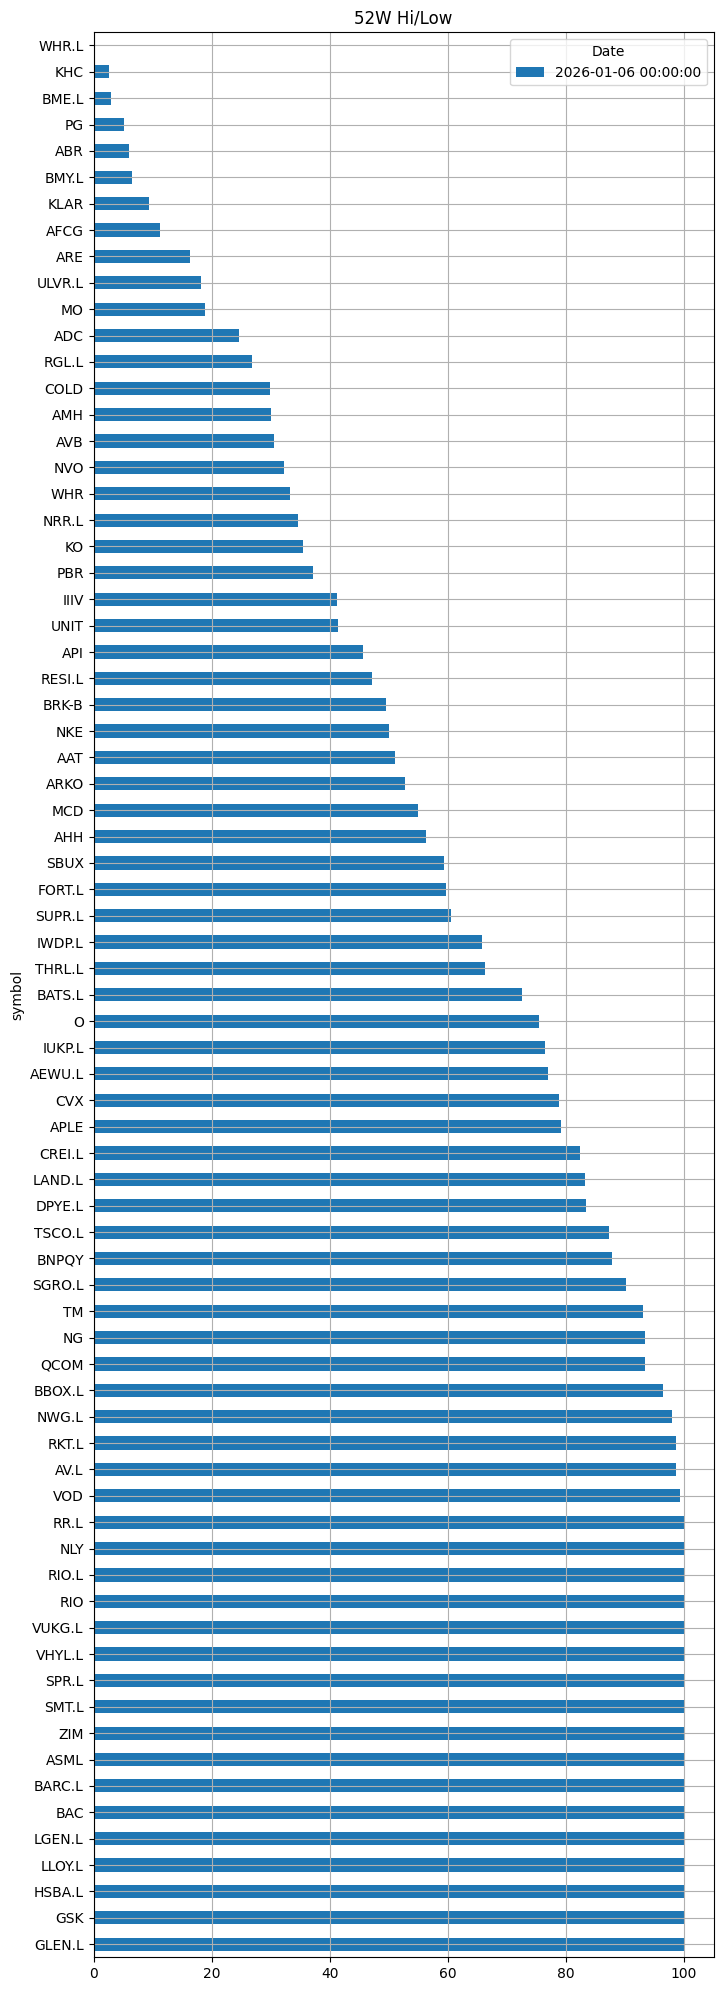

In [55]:
avg_pct = i52whlpl_all[col].mean()
min_pct = i52whlpl_all[col].min()
max_pct = i52whlpl_all[col].max()
chart_title = '52W Hi/Low % Position  |  Avg: {:.1f}%  Min: {:.1f}%  Max: {:.1f}%  (as of {})'.format(avg_pct, min_pct, max_pct, col)
fig52whl = i52whlpl_all.sort_values(by=[col], ascending=False).plot(kind='barh', figsize=(8,25), grid=True, title=chart_title).get_figure()

In [56]:
# SA.getGainerLosers(pvt)

In [57]:
top_gainer_losers = SA.getGainerLosers(pvt).dropna()

In [58]:
# pvt["1YHLP"]

In [59]:
t1mhl, t3mhl, t6mhl, t1yhl = SA.getProcessedByMilestone(pvt)

In [60]:
style_text = """
<meta name="viewport" content="width=device-width, initial-scale=1">
<style>
* {
  box-sizing: border-box;
}

/* Create two equal columns that floats next to each other */
.col {
  float: left;
  width: 50%;
}

/* Clear floats after the columns */
.row:after {
  width: 50%;
}
</style>

"""

In [61]:
# email
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.image import MIMEImage
import os
from base64 import b64encode




me  = 'peri47.study@gmail.com'
recipient = 'peri47.t@gmail.com'
# recipient = ['peri47.study@gmail.com', 'rite2peri@gmail.com', 'peri47.t@gmail.com']
subject = 'Signals for {}'.format('LSE')

email_server_host = 'smtp.gmail.com'
port = 587
email_username = 'peri47.t@gmail.com'
email_password = 'fxxj aell fnzr urmb'


msg = MIMEMultipart('alternative')
msg['From'] = me
msg['To'] = recipient
msg['Subject'] = subject
img_format = 'png'


msg.add_header('Content-Type','text/html')
section1 = """\
<html>
    <head> 
    {style_text}
    </head>
    <body>
            <H1>Stocks in Golden X - Signals: </H1>
            {signal_goldenx}
            <H1>Stocks nearing Golden X : </H1>
            {nearing_goldenx}
        <div class="row">
            <div class="col">
            <H1> %  From 52W H/L - Top 10: (Near Low)</H1>
            {hl52w_top10}
            </div>
            <div class="col">
            <H1>% From 52W H/L - Bottom10: (Near High)</H1>
            {hl52w_last10}
            </div>
        </div>
        <section>
        <div class="row">        
            <div class="col">
            <H1> 1 week Hi </H1>
            {h1w}
            </div>
            <div class="col">
            <H1> 1 weekLow </H1>
            {l1w}
            </div>
        </div>
        </section>
        <section>
        <div class="row">        
            <div class="col">
            <H1> 3 month Hi </H1>
            {h3m}
        </div>
        <div class="row">        
            <H1> 3 month low </H1>
            {l3m}
        </div>
        </div>
        </section>
        <section>
            <H1> Top Gainers / Losers  </H1>
                    <H1> 1 Week losers </H1>
                    {l1wl}
                    <H1> 1 Week gainers </H1>
                    {l1wh}
            <H1> 1 Month losers </H1>
            {l1ml}
            <H1> 1 Month gainers </H1>
            {l1mh}
            <H1> 3 Month losers </H1>
            {l3ml}
            <H1> 3 Month gainers </H1>
            {l6mh}
            <H1> 6 Month losers </H1>
            {l6ml}
            <H1> 6 Month gainers </H1>
            {l3mh}
        </section>
        
    </body>
</html>
""".format(nearing_goldenx=ip.to_html(),
           signal_goldenx=sp.to_html(),
           hl52w_top10 = i52whlpl_all.dropna().sort_values(by=[col]).head(10).to_html(), 
           hl52w_last10 = i52whlpl_all.dropna().sort_values(by=[col]).tail(10).to_html(),
           h1w = t1mhl.tail(10).to_html() , l1w = t1mhl.head(10).to_html() , h3m = t3mhl.tail(10).to_html(),
           l3m= t3mhl.head(10).to_html(),
           l1wl = top_gainer_losers.sort_values(by=['1wd']).head(10).to_html(),
           l1wh = top_gainer_losers.sort_values(by=['1wd']).tail(10).to_html(),
           l1ml = top_gainer_losers.sort_values(by=['1md']).head(10).to_html(),
           l1mh = top_gainer_losers.sort_values(by=['1md']).tail(10).to_html(),
           l3ml = top_gainer_losers.sort_values(by=['3md']).head(10).to_html(),
           l3mh = top_gainer_losers.sort_values(by=['3md']).tail(10).to_html(),
           l6ml = top_gainer_losers.sort_values(by=['6md']).head(10).to_html(),
           l6mh = top_gainer_losers.sort_values(by=['6md']).tail(10).to_html(),
           style_text = style_text,
           date=col )
email_body = section1
# msg.a

msg.attach(MIMEText(section1, 'html'))

# msgimg = 
msg.attach(MIMEImage(SA.getImgData(fig52whl)))
msg.attach(MIMEImage(fig52whlclr))

try:
    ipfig
except: 
    #ignore
    print('')
else:
    msg.attach(MIMEImage(SA.getImgData(ipfig)))

# attach top_gainer_losers as csv
csvattach = MIMEText(top_gainer_losers.sort_values(by=['6md']).to_csv())
csvattach.add_header("Content-Disposition", "attachment", filename='lseg_top_gainer_losers.csv')
msg.attach(csvattach)


# attach signal SMA20_2_200P as csv
csvattach = MIMEText(pvt.SMA20_2_200P.tail(SIGNAL_WINDOW).T.to_csv())
csvattach.add_header("Content-Disposition", "attachment", filename='SMA20_2_200P.csv')
msg.attach(csvattach)

try:
    spfig
except: 
    #ignore
    print('')
else:
    msg.attach(MIMEImage(SA.getImgData(spfig)))

# f = open("./test.html", "w")
# f.write(section1)
# f.close()

In [62]:
server = smtplib.SMTP(email_server_host, port)
server.ehlo()
server.starttls()
server.login(email_username, email_password)
server.sendmail(me, recipient, msg.as_string())
server.close()